In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 3
sc.settings.figdir = '../results/'

adata = sc.read_h5ad('../data/pbmc3k_clustered.h5ad')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


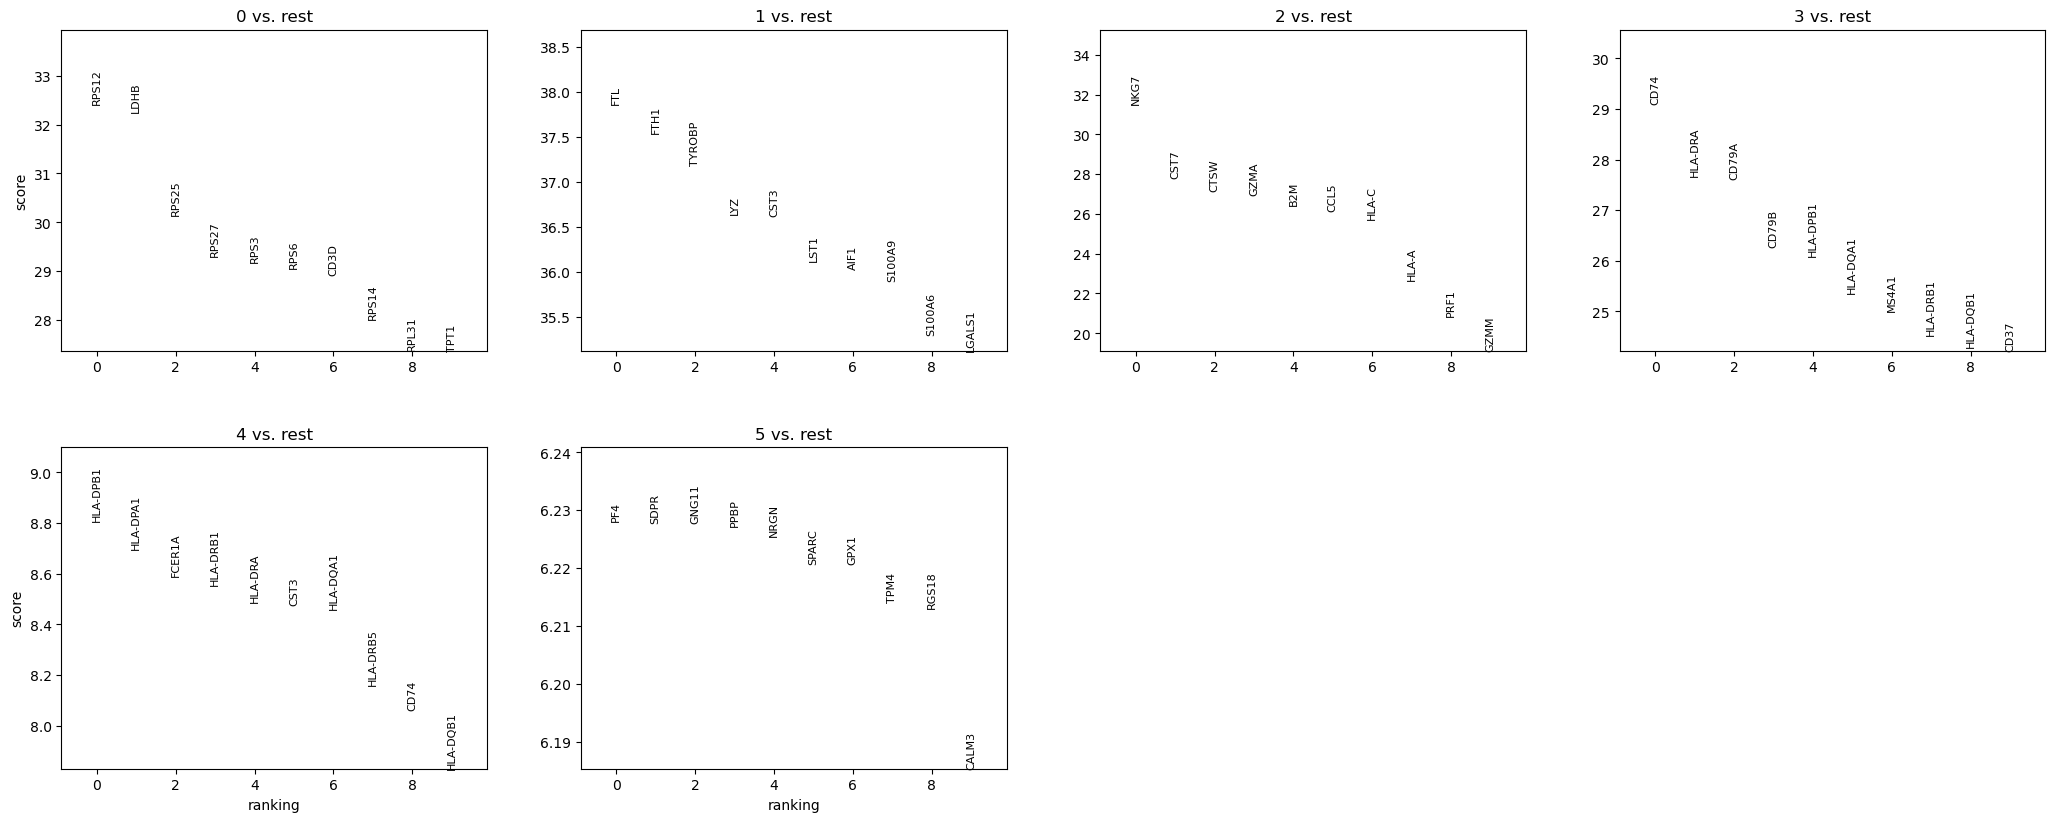

In [2]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

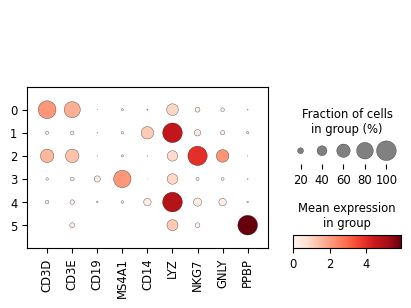

In [3]:
marker_genes = [
    'CD3D', 'CD3E',    # T cells
    'CD19', 'MS4A1',   # B cells
    'CD14', 'LYZ',     # Monocytes
    'NKG7', 'GNLY',    # NK cells
    'PPBP'             # Megakaryocytes
]

sc.pl.dotplot(adata, marker_genes, groupby='leiden')

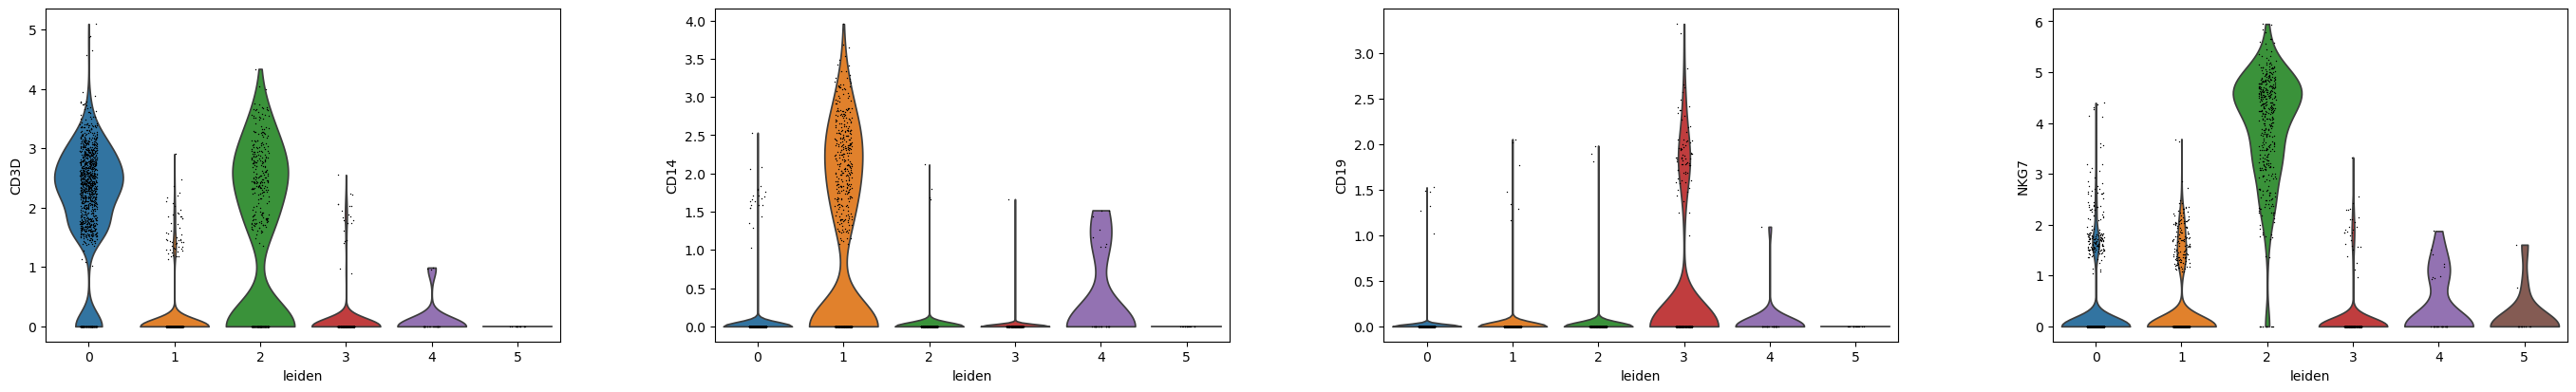

In [4]:
sc.pl.violin(adata, ['CD3D', 'CD14', 'CD19', 'NKG7'], groupby='leiden')

In [5]:
cell_type_map = {
    '0': 'CD4 T cells',        # CD3D, CD3E high + IL7R
    '1': 'CD14 Monocytes',     # CD14, LYZ high
    '2': 'B cells',            # CD19, MS4A1 high
    '3': 'CD8 T cells',        # CD3D + cytotoxic genes
    '4': 'NK cells',           # NKG7, GNLY — cytotoxic but no CD3
    '5': 'FCGR3A Monocytes',   # non-classical monocyte subtype
    '6': 'Dendritic cells',    # small cluster, antigen-presenting genes
    '7': 'Megakaryocytes'      # PPBP high — platelet precursors
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map)


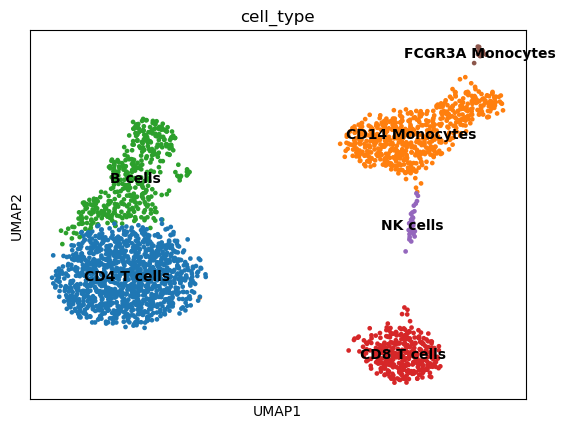

In [6]:
sc.pl.umap(adata, color='cell_type', legend_loc='on data')


In [7]:
cell_counts = adata.obs['cell_type'].value_counts()
total = adata.n_obs

print(f"Total cells: {total}\n")
print(f"{'Cell type':<25} {'Count':>6} {'Percentage':>10}")
print("-" * 45)
for cell_type, count in cell_counts.items():
    pct = (count / total) * 100
    print(f"{cell_type:<25} {count:>6} {pct:>9.1f}%")

Total cells: 2638

Cell type                  Count Percentage
---------------------------------------------
CD4 T cells                 1188      45.0%
CD14 Monocytes               635      24.1%
B cells                      428      16.2%
CD8 T cells                  345      13.1%
NK cells                      29       1.1%
FCGR3A Monocytes              13       0.5%


In [8]:
import os
os.makedirs('../data', exist_ok=True)

adata.write('../data/pbmc3k_annotated.h5ad')
print("Pipeline complete — annotated object saved")

Pipeline complete — annotated object saved
